# imports

In [3]:
from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    r2_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import numpy as np

# Question 1

In [4]:
def linear_fitter(Xtrain, ytrain, Xtest):
    # fit model
    linear_model = LinearRegression()
    linear_model.fit(Xtrain, ytrain)

    ypred = linear_model.predict(Xtest)
    r2 = r2_score(y_pred=ypred, y_true=ytest)
    return (r2, linear_model.coef_, linear_model.intercept_)

In [5]:
# use as_frame parameter to fetch function return a dataframe
housing_data = fetch_california_housing(as_frame=True)
df_housing_m = housing_data.frame
df_housing_s = df_housing_m.loc[:, ["MedInc", "HouseAge", "AveRooms", "MedHouseVal"]]
print("data frame loaded successfuly!")

data frame loaded successfuly!


In [6]:
display(df_housing_s.head(5))
print(df_housing_s.info())
display(df_housing_s.describe())

,MedInc,HouseAge,AveRooms,MedHouseVal
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   MedHouseVal  20640 non-null  float64
dtypes: float64(4)
memory usage: 645.1 KB
None


,MedInc,HouseAge,AveRooms,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,2.068558
std,1.899822,12.585558,2.474173,1.153956
min,0.499900,1.000000,0.846154,0.149990
25%,2.563400,18.000000,4.440716,1.196000
50%,3.534800,29.000000,5.229129,1.797000
75%,4.743250,37.000000,6.052381,2.647250
max,15.000100,52.000000,141.909091,5.000010


Xtrain shape (14448, 1)
ytrain shape (14448,)
Xtest shape (6192, 1)
ytest shape (6192,)


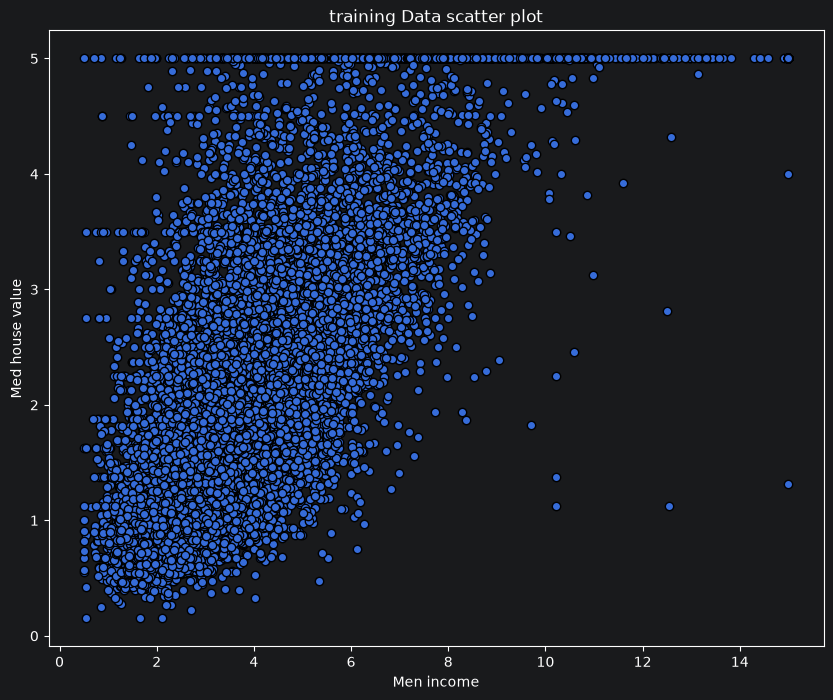

In [7]:
# split datas
Xtrain, Xtest, ytrain, ytest = train_test_split(
    df_housing_s["MedInc"].to_frame(),
    df_housing_s["MedHouseVal"],
    test_size=0.3,
    random_state=42,
)

print(
    f"Xtrain shape {Xtrain.shape}\nytrain shape {ytrain.shape}\nXtest shape {Xtest.shape}\nytest shape {ytest.shape}"
)


# visualize train data
plt.figure(figsize=(10, 8))
plt.scatter(Xtrain, ytrain, edgecolors="black")
plt.title("training Data scatter plot")
plt.xlabel("Men income")
plt.ylabel("Med house value")
plt.show()

In [8]:
r2_result, coef, intercept = linear_fitter(Xtrain, ytrain, Xtest)
print(
    f"R2 score = {r2_result:.2f}\nCoefficient = {coef[0]:.2f}\nIntercept = {intercept:.2f}"
)

R2 score = 0.47
Coefficient = 0.42
Intercept = 0.45


# use three features

In [9]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    df_housing_s.loc[:, ["MedInc", "HouseAge", "AveRooms"]],
    df_housing_s["MedHouseVal"],
    test_size=0.3,
    random_state=42,
)

print(
    f"Xtrain shape {Xtrain.shape}\nytrain shape {ytrain.shape}\nXtest shape {Xtest.shape}\nytest shape {ytest.shape}"
)


# visualize train data

Xtrain shape (14448, 3)
ytrain shape (14448,)
Xtest shape (6192, 3)
ytest shape (6192,)


In [10]:
r2_result, coef, intercept = linear_fitter(Xtrain, ytrain, Xtest)
print(
    f"R2 score = {r2_result:.2f}\nCoefficient = {coef[0]:.2f}\nIntercept = {intercept:.2f}"
)

R2 score = 0.51
Coefficient = 0.44
Intercept = 0.01


# Question 2

# PART A

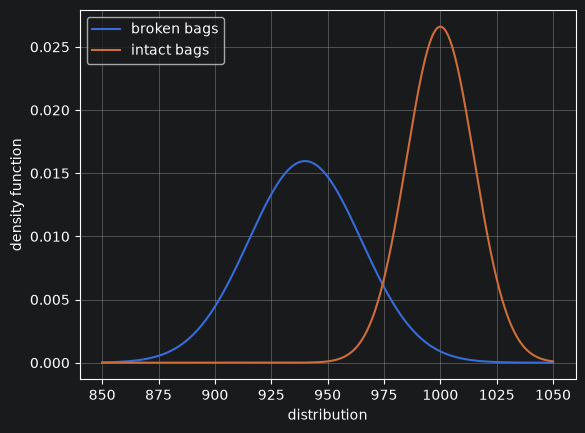

In [11]:
np.random.seed(42)
prior_intact = 0.92
prior_broken = 0.08
dist_intact = norm(1000, 15)
dist_broken = norm(940, 25)
X = np.linspace(850, 1050, 1000)

plt.plot(X, dist_broken.pdf(X), label="broken bags")
plt.plot(X, dist_intact.pdf(X), label="intact bags")
plt.legend()
plt.grid()
plt.ylabel("density function")
plt.xlabel("distribution")
plt.show()

In [12]:
new_x = 970

j_p_broken = prior_broken * (dist_broken.pdf(new_x))
j_p_intact = prior_intact * (dist_intact.pdf(new_x))

# p(x)
p_x = j_p_broken + j_p_intact

# posterior
p_intact = prior_intact * (dist_intact.pdf(new_x)) / p_x
p_broken = prior_broken * (dist_broken.pdf(new_x)) / p_x
print(f"proability X=970 for each class\nintact {p_intact:.2f}%\n\
broken {p_broken:.2f}%\nSum probabilities {p_broken+p_intact}")

proability X=970 for each class
intact 0.84%
broken 0.16%
Sum probabilities 1.0


# KNN | part B

In [13]:
def knn_fitter(Xtrain, ytrain, Xtest, k=3):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xtrain, ytrain)
    ypred = model.predict(Xtest)
    return ypred

In [14]:
# load dataset
X, y = load_wine(return_X_y=True)
print(f"X.shape {X.shape},y.shape {y.shape}")
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=42, stratify=y)

scaler = StandardScaler()

scaler.fit(Xtrain)
Xtrain_s = scaler.transform(Xtrain)
Xtest_s = scaler.transform(Xtest)

# k -1
ypred_1 = knn_fitter(Xtrain, ytrain, Xtest, k=1)
acc_1 = accuracy_score(y_pred=ypred_1, y_true=ytest)
print(f"accuracy k = 1 : {acc_1:.2f}")
# k -5
ypred_5 = knn_fitter(Xtrain, ytrain, Xtest, k=5)
acc_5 = accuracy_score(y_pred=ypred_5, y_true=ytest)
print(f"accuracy k = 5 : {acc_5:.2f}")

# k -15
ypred_15 = knn_fitter(Xtrain, ytrain, Xtest, k=15)
acc_15 = accuracy_score(y_pred=ypred_15, y_true=ytest)
print(f"accuracy k = 15 : {acc_15:.2f}")


# smaller k has more risk for overfitting
# bigger k has more risk for underfitting
# good k => good fit

# we scaled the datas becaues the KNN is a distance base model and in euclidian distance scale is matter
# if features have different scales bigger scale will has bigger importance

X.shape (178, 13),y.shape (178,)
accuracy k = 1 : 0.73
accuracy k = 5 : 0.78
accuracy k = 15 : 0.78


# Question 3

In [15]:
from collections import Counter

df = pd.read_csv(r"E:\Maktab-145\Datasets\titanic.csv")

X = df.loc[:, ["Pclass", "Sex", "Age", "Fare"]].copy()

sex_dummies = pd.get_dummies(X["Sex"], prefix="Sex", drop_first=True)
X = pd.concat([X.drop(columns=["Sex"]), sex_dummies], axis=1)
X.fillna(X.mean(axis=0), inplace=True)
sex_encoder = LabelEncoder()
X["Sex_male"] = sex_encoder.fit_transform(X["Sex_male"])


y = df.loc[:,"Survived"]



Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
Xtrain_s = scaler.fit_transform(Xtrain)
Xtest_s = scaler.transform(Xtest)


In [16]:
model_log = LogisticRegression()
model_log.fit(Xtrain_s, ytrain)
ypred = model_log.predict(Xtest_s)
acc = accuracy_score(ytest, ypred)
print(f"train accuracy {model_log.score(Xtrain_s, ytrain):.2f}")
print(f"test accuracy = {acc:.2f}")

train accuracy 0.80
test accuracy = 0.81


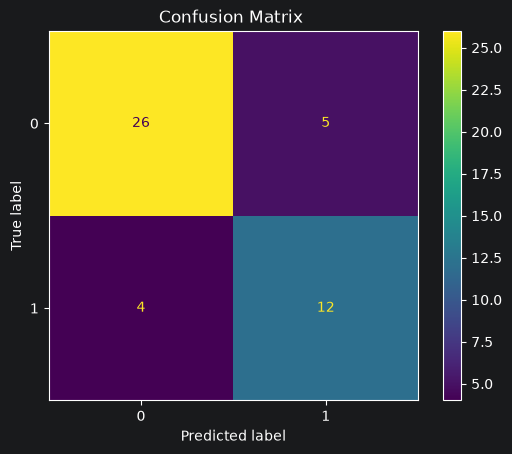

model coefficients  
[[-0.54664886 -0.25454177 -0.31211797 -1.18387879]]


In [17]:
conf = confusion_matrix(ytest, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf, display_labels=model_log.classes_)
disp.plot()
plt.title("Confusion Matrix ")
plt.show()

coefs = model_log.coef_
print(f"model coefficients  \n{coefs}")

In [18]:
# predict proba and loss function
bad_classified_idx = np.where(ytest != ypred)[0][0]
good_classified_idx = np.where(ytest == ypred)[0][0]

ytest = np.array(ytest)
proba = model_log.predict_proba(Xtest_s)

# نمونه درست
good_y = ytest[int(good_classified_idx)].reshape(-1)
good_p = proba[int(good_classified_idx), :].reshape(1, -1)
good_loss = log_loss(good_y, good_p, labels=[0, 1])

# نمونه غلط
bad_y = ytest[int(bad_classified_idx)].reshape(-1)
bad_p = proba[int(bad_classified_idx), :].reshape(1, -1)
bad_loss = log_loss(bad_y, bad_p, labels=[0, 1])

print("Good Loss:", good_loss)
print("Bad Loss:", bad_loss)

Good Loss: 0.16131354527642625
Bad Loss: 1.120443944578581


# Question 4

In [19]:
healthy = 240
dangerous = 60
n = 300
p_h = healthy / n
p_d = dangerous / n

# Gini
gini = 1 - (p_h**2 + p_d**2)
print(f"Gini impurity root {gini:.2f}")

# entropy -(p healthy * log2 p healthy + p dangerous * log2 P dangerous)
entropy = -(p_h*np.log2(p_h) + p_d*np.log2(p_d))
print(f"Entropy impurity root {entropy:.2f}")

# فرزند چپ و راست
l_h, l_d = 180, 10
r_h, r_d = 60, 50

n_l = l_h + l_d  # 190
n_r = r_h + r_d  # 110

# 1. Gini فرزندان
gini_l = 1 - ((l_h/n_l)**2 + (l_d/n_l)**2)
gini_r = 1 - ((r_h/n_r)**2 + (r_d/n_r)**2)

# میانگین وزنی Gini
weighted_gini = (n_l/n) * gini_l + (n_r/n) * gini_r

# 2. Entropy فرزندان
p_lh, p_ld = l_h/n_l, l_d/n_l
p_rh, p_rd = r_h/n_r, r_d/n_r

entropy_l = -(p_lh*np.log2(p_lh) + p_ld*np.log2(p_ld))
entropy_r = -(p_rh*np.log2(p_rh) + p_rd*np.log2(p_rd))

# Information Gain = Entropy ریشه - میانگین وزنی Entropy فرزندان
weighted_entropy = (n_l/n) * entropy_l + (n_r/n) * entropy_r
info_gain = entropy - weighted_entropy

print(f"Gini Left: {gini_l:.3f}, Right: {gini_r:.3f}")
print(f"Weighted Gini: {weighted_gini:.3f}")
print(f"Information Gain: {info_gain:.3f}")

# linear models only can solve linear problems
# when the problem is like XOR gate
# only a non-linear model like trees can solve the issue
# because a tree use conditions for classification not a linear function



Gini impurity root 0.32
Entropy impurity root 0.72
Gini Left: 0.100, Right: 0.496
Weighted Gini: 0.245
Information Gain: 0.169


In [20]:
from collections import Counter

df = pd.read_csv(r"E:\Maktab-145\Datasets\titanic.csv")

X = df.loc[:, ["Pclass", "Sex", "Age", "Fare"]].copy()

sex_dummies = pd.get_dummies(X["Sex"], prefix="Sex", drop_first=True)
X = pd.concat([X.drop(columns=["Sex"]), sex_dummies], axis=1)
X.fillna(X.mean(axis=0), inplace=True)
sex_encoder = LabelEncoder()
X["Sex_male"] = sex_encoder.fit_transform(X["Sex_male"])


y = df.loc[:,"Survived"]



Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [21]:
tree = DecisionTreeClassifier(max_depth=4)
tree.fit(Xtrain,ytrain)
ypred_tree = tree.predict(Xtest)
tree_accuracy = accuracy_score(ytest, ypred_tree)

print(f"tree accuracy {tree_accuracy:.2f} VS Logistic Regression accuracy {acc:.2f}")
print(f"feature importance {tree.feature_importances_}")

tree accuracy 0.79 VS Logistic Regression accuracy 0.81
feature importance [0.0771361  0.12114878 0.24247364 0.55924149]


In [22]:
df = pd.read_csv(r"E:\Maktab-145\Datasets\heart.csv")



In [23]:
display(df.head(5))
X = df.loc[:,["age","chol","thal"]]
y = df.iloc[:,-1]

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
print(
f"shapes Xtrain {Xtrain.shape},Xtest\
{Xtest.shape}\n,ytrain {ytrain.shape},ytest {ytest.shape}"
)



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


shapes Xtrain (212, 3),Xtest(91, 3)
,ytrain (212,),ytest (91,)


In [26]:
tree_unlimited = DecisionTreeClassifier()
tree_unlimited.fit(Xtrain,ytrain)

tree_leaf_20 = DecisionTreeClassifier(min_samples_leaf=20)
tree_leaf_20.fit(Xtrain,ytrain)

tree_nodes_8 = DecisionTreeClassifier(max_leaf_nodes=8)
tree_nodes_8.fit(Xtrain,ytrain)

# Calculate accuracy for train,test for each model
print(f"Accuracy unlimited train: {tree_unlimited.score(Xtrain,ytrain)}")
print(f"Accuracy unlimited test: {tree_unlimited.score(Xtest,ytest)}")

print(f"Accuracy leaf node 8 train: {tree_nodes_8.score(Xtrain,ytrain)}")
print(f"Accuracy leaf node 8 test: {tree_nodes_8.score(Xtest,ytest)}")

print(f"Accuracy min sample leaf = 20  train: {tree_leaf_20.score(Xtrain,ytrain)}")
print(f"Accuracy min sample leaf = 20  test: {tree_leaf_20.score(Xtest,ytest)}")




Accuracy unlimited train: 1.0
Accuracy unlimited test: 0.6263736263736264
Accuracy leaf node 8 train: 0.8207547169811321
Accuracy leaf node 8 test: 0.6703296703296703
Accuracy min sample leaf = 20  train: 0.7735849056603774
Accuracy min sample leaf = 20  test: 0.6813186813186813


max_depth 1 & accuracy 0.7032967032967034
max_depth 2 & accuracy 0.7142857142857143
max_depth 3 & accuracy 0.6813186813186813
max_depth 4 & accuracy 0.6813186813186813
max_depth 5 & accuracy 0.6703296703296703
max_depth 6 & accuracy 0.6483516483516484
max_depth 7 & accuracy 0.6153846153846154
max_depth 8 & accuracy 0.6153846153846154


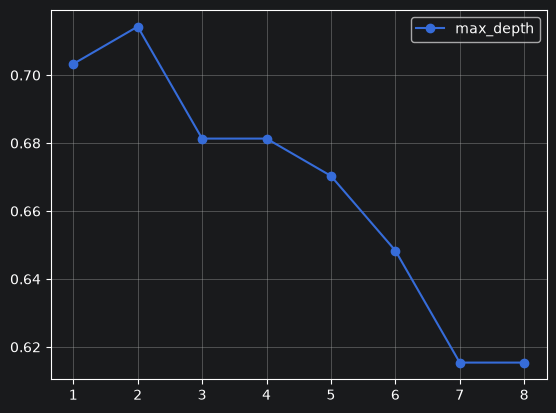

In [36]:
max_depths = range(1,9)
accs = []
for max_depth in max_depths:
    tree = DecisionTreeClassifier(max_depth=max_depth)
    tree.fit(Xtrain,ytrain)
    print(f"max_depth {max_depth} & accuracy {tree.score(Xtest,ytest)}")
    accs.append(tree.score(Xtest,ytest))

plt.plot(max_depths,accs ,marker='o',label="max_depth")
plt.legend()
plt.grid()
plt.show()